### SUPPORT VECTOR MACHINE

#### Task 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

- 1.	Load the dataset and perform fundamental data exploration.

In [2]:
df = pd.read_csv('Pharma_Industry.csv')
df.head(10)

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
5,-0.535963,0.070851,0.808058,0.330542,-0.065926,0
6,-0.641487,-1.820620,0.487872,-0.276917,0.938309,0
7,1.901191,-0.072931,-0.060661,0.944914,-0.573190,1
8,0.213197,-0.356843,-0.751969,-1.231773,-2.180044,1
9,0.409819,0.929821,-0.241258,-1.561815,-1.249890,0


In [3]:
df.shape

(500, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [5]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


- The predictor variables appear to have been standardized before being provided in the dataset. Therefore, negative values represent observations below the feature mean in standardized units and do not represent physically negative drug dosage, blood pressure, heart rate, or glucose measurements.

In [6]:
stats = pd.DataFrame({
    'Mean' : df.mean(),
    'Median': df.median(),
    'Standard Deviation' : df.std(),
    'Min' : df.min(),
    'Max' : df.max(),
    'Q1' : df.quantile(0.25),
    'Q2' : df.quantile(0.50),
    'Q3' : df.quantile(0.75),
    'IQR' : df.quantile(0.75) - df.quantile(0.25),
    'Missing Values' : df.isnull().sum()
})
stats

,Mean,Median,Standard Deviation,Min,Max,Q1,Q2,Q3,IQR,Missing Values
Drug Dosage (mg),-0.037761,-0.019340,0.979891,-3.019512,2.949094,-0.642003,-0.019340,0.641151,1.283153,0
Systolic Blood Pressure (mmHg),0.214957,0.201532,1.247567,-3.773897,4.111751,-0.565168,0.201532,0.951375,1.516543,0
Heart Rate (BPM),0.062871,0.027732,0.971978,-2.940389,3.193108,-0.648157,0.027732,0.710774,1.358931,0
Liver Toxicity Index (U/L),0.054398,-0.065661,0.986001,-3.401277,3.373269,-0.586085,-0.065661,0.633914,1.219999,0
Blood Glucose Level (mg/dL),-0.171863,-0.108106,0.983765,-3.110431,2.518023,-0.797715,-0.108106,0.513555,1.311270,0
Drug Response,0.520000,1.000000,0.500100,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0


In [7]:
print("No. of Duplicate rows :", df.duplicated().sum())

No. of Duplicate rows : 0


In [8]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

- 2.	Utilize histograms, box plots, or density plots to understand feature distributions.

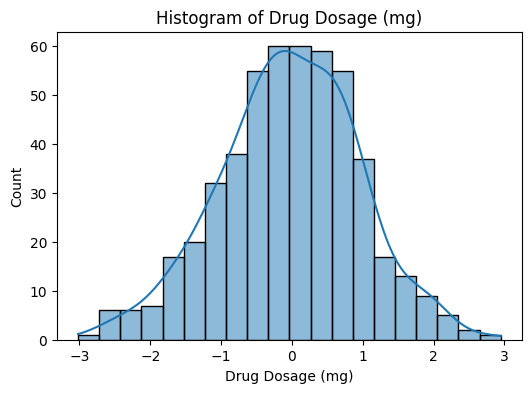

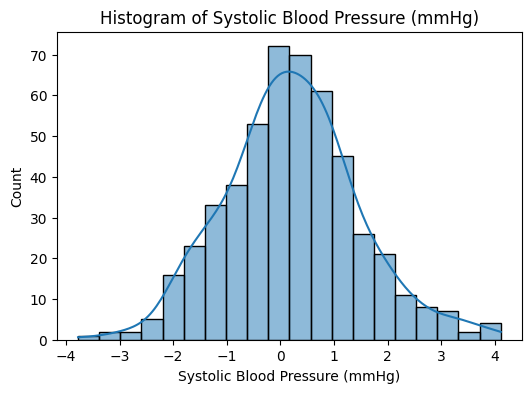

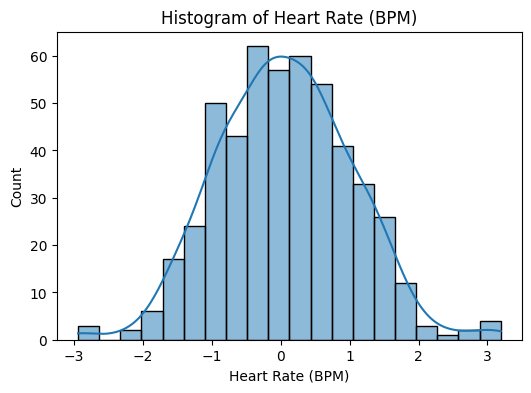

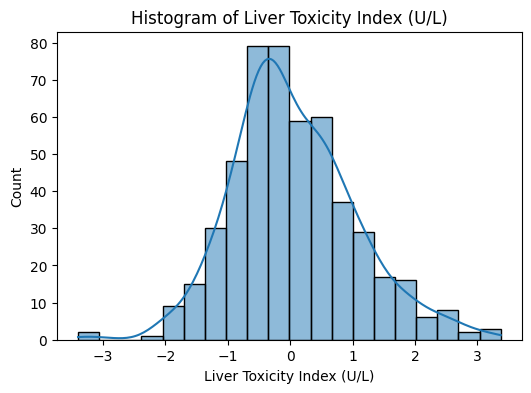

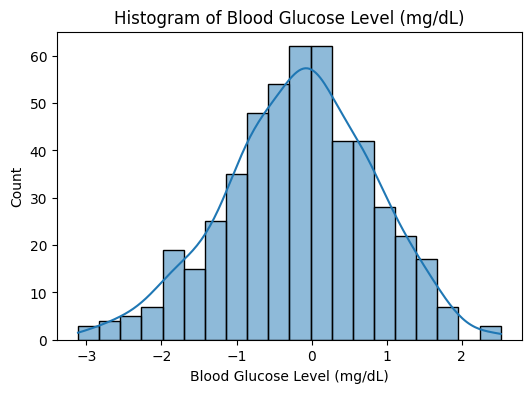

In [9]:
num_col = ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)']
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

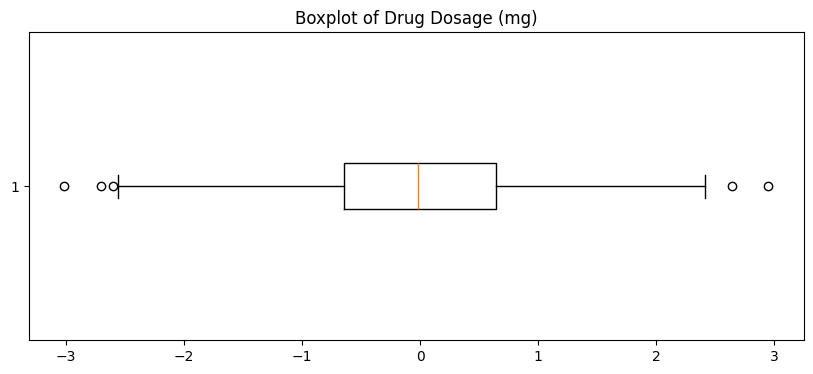

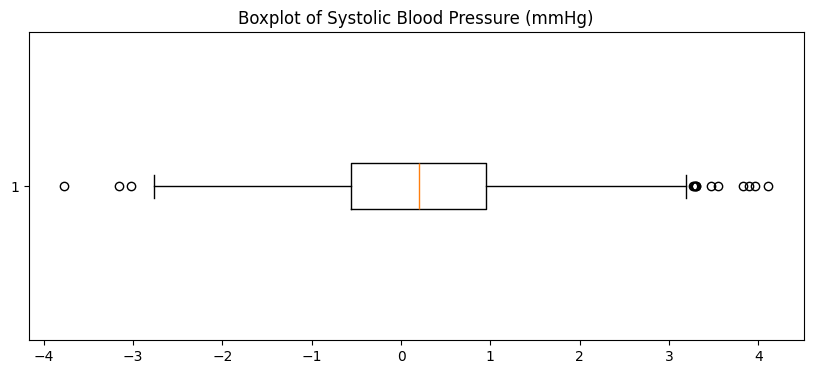

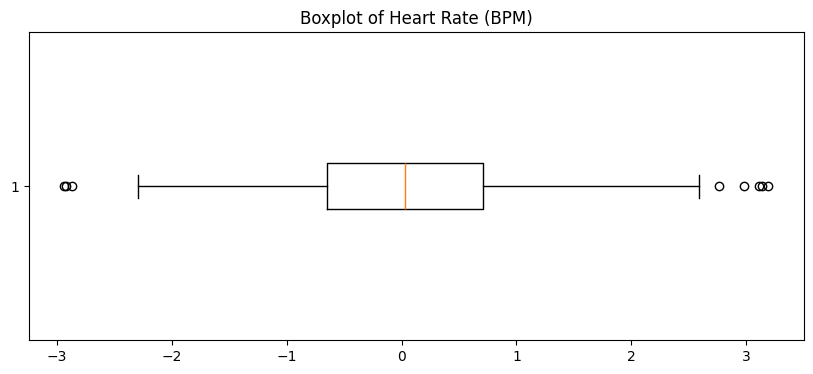

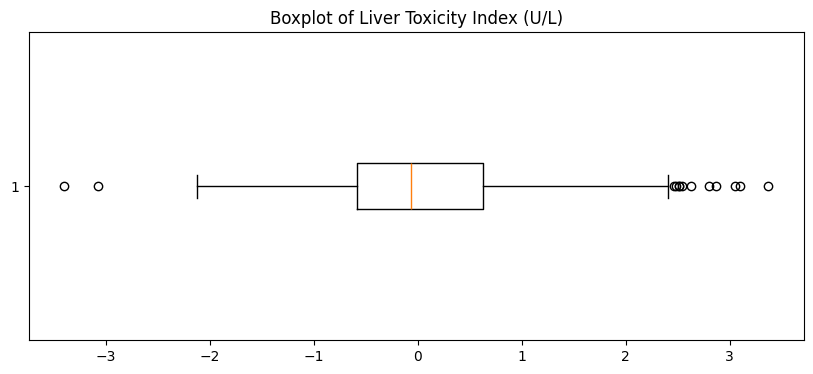

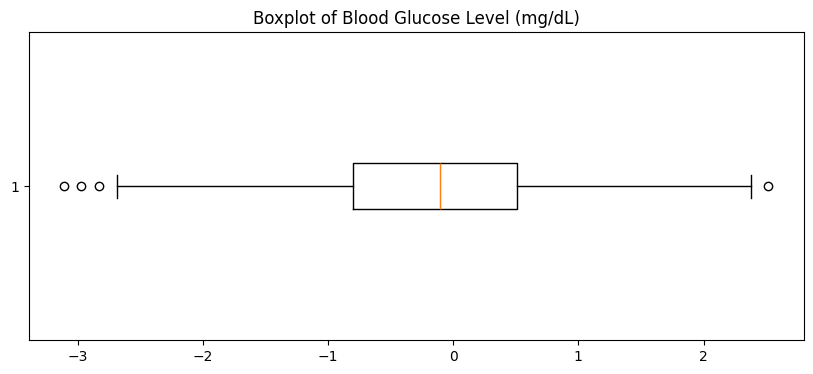

In [10]:
for col in num_col:
    plt.figure(figsize=(10,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

- 3.	Investigate feature correlations to discern relationships within the data.

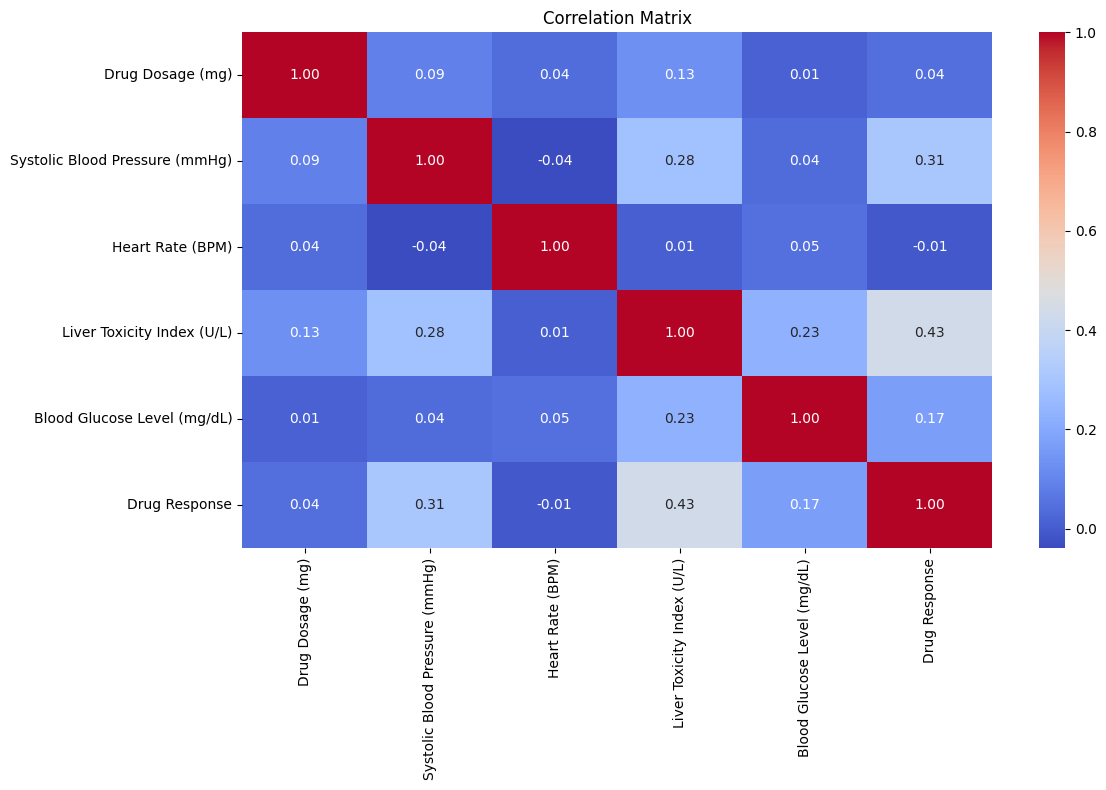

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap = 'coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#### Task 2: Data Preprocessing

- 1.	Encode categorical variables if necessary - There are no Categorical variables in the dataset so encoding is not nessasary
- 2.	Split the dataset into training and testing sets.

In [12]:
X = df.drop('Drug Response', axis = 1)
y = df['Drug Response']

In [13]:
X.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
dtype: object

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


#### Task 3: Data Visualization

- 1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
- 2.	Visualize class distributions to gauge dataset balance or imbalance.

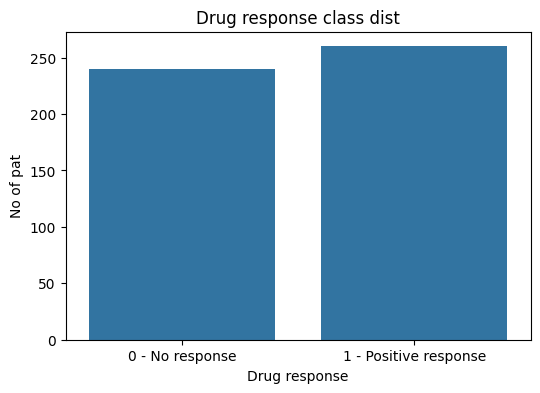

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['Drug Response'])
plt.title("Drug response class dist")
plt.xlabel('Drug response')
plt.ylabel('No of pat')
plt.xticks([0,1],["0 - No response", "1 - Positive response"])
plt.show()

- The class distribution is relatively balanced, with 48% of observations belonging to the No Response class and 52% belonging to the Positive Response class. Therefore, there is no significant class imbalance.

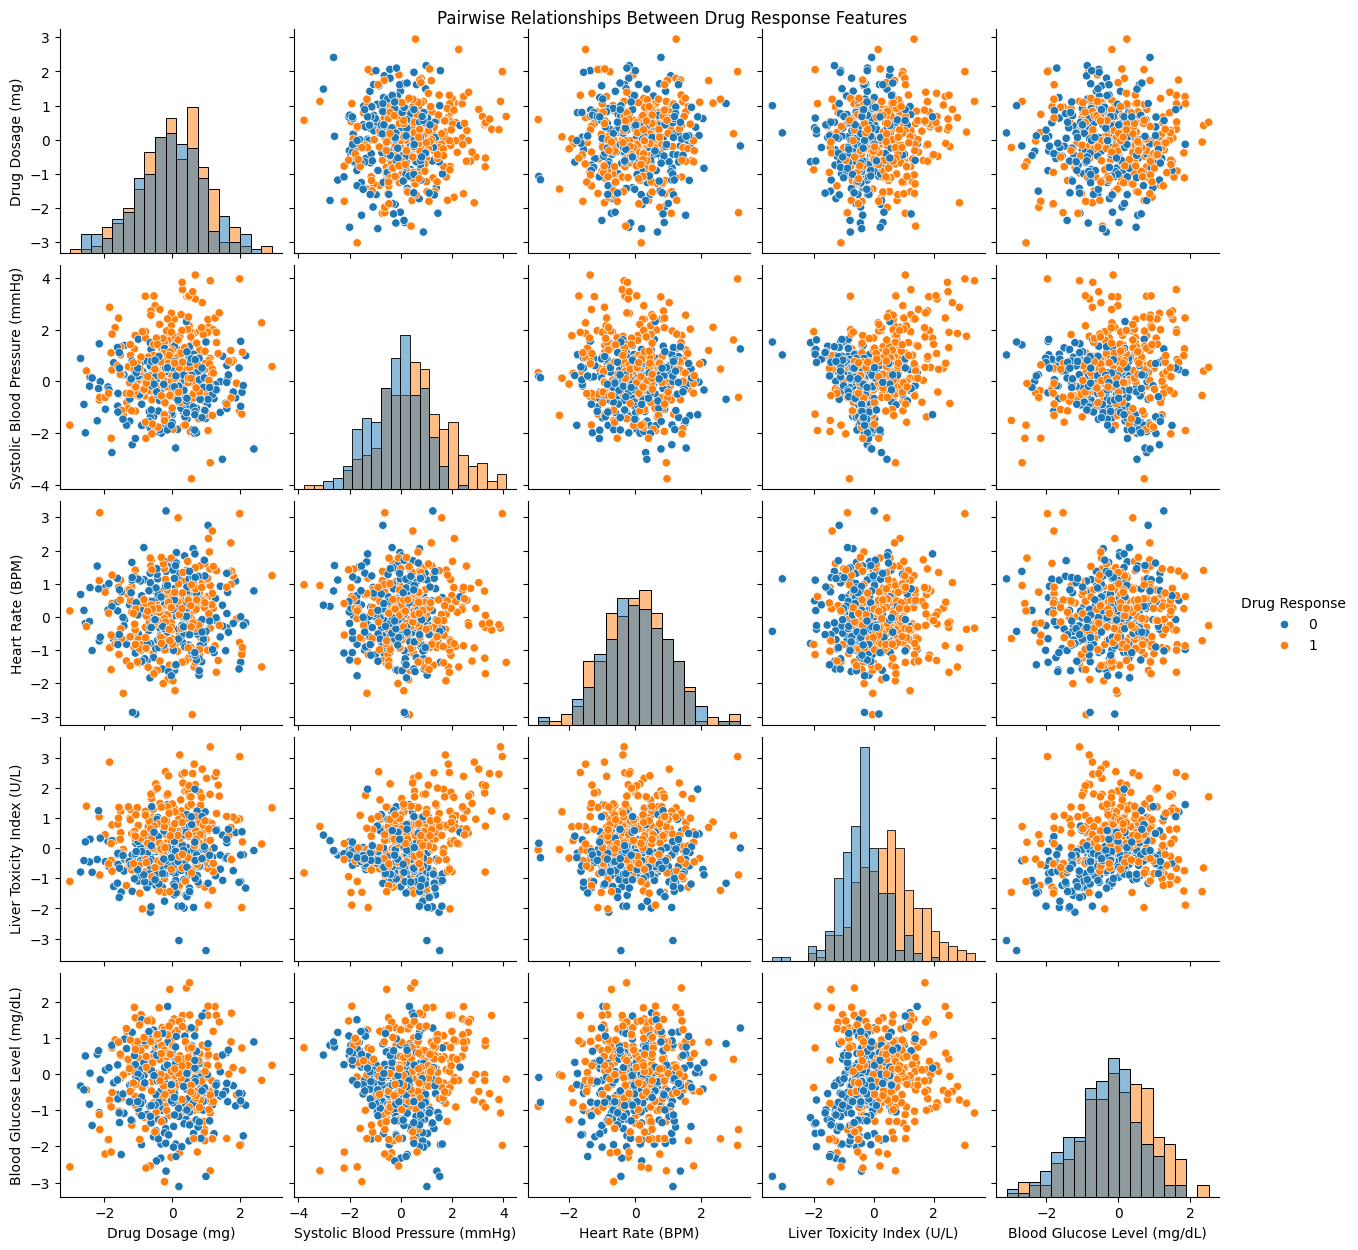

In [17]:
sns.pairplot(
    df,
    hue='Drug Response',
    diag_kind='hist'
)
plt.suptitle("Pairwise Relationships Between Drug Response Features", y=1)
plt.show()

#### Task 4: SVM Implementation

- 1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
- 2.	Train the SVM model on the training data.
- 3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [18]:
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])
svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [19]:
y_pred = svm_model.predict(X_test)
print("Predictions :")
print(y_pred)

Predictions :
[1 1 1 0 0 1 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 1 1
 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 0 1 1 1 1 1 1 0
 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1]


In [20]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print(f"Accuracy Score : {accuracy:.2f}")
print(f"Precision Score : {precision:.2f}")
print(f"Recall Score: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy Score : 0.77
Precision Score : 0.75
Recall Score: 0.83
F1 Score: 0.79


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



#### Task 5: Visualization of SVM Results

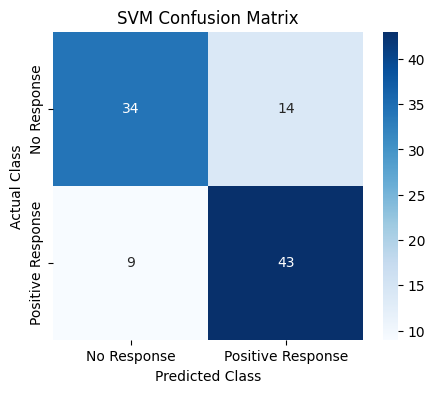

In [22]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Response',"Positive Response"],
    yticklabels=['No Response',"Positive Response"]
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SVM Confusion Matrix")
plt.show()

- The confusion matrix shows the number of correctly and incorrectly classified observations for both drug-response classes. It allows us to distinguish true positives, true negatives, false positives and false negatives.

#### Task 6: Parameter Tuning and Optimization

1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

In [23]:
kernels = ['linear', 'poly', 'rbf']
results = []
for kernel in kernels:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel=kernel))
    ])
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results.append({
        'Kernel': kernel,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions)
    })
results_df = pd.DataFrame(results)
results_df

,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.72,0.760870,0.673077,0.714286
1,poly,0.65,0.666667,0.653846,0.660194
2,rbf,0.77,0.754386,0.826923,0.788991


- The RBF kernel achieved the highest accuracy of 77% and the highest F1-score of approximately 78.9%. It also achieved the highest recall of approximately 82.7% for the positive-response class. The polynomial kernel performed the worst, while the linear kernel produced intermediate results. This suggests that the relationship between the features and drug response may contain nonlinear patterns that are better captured by the RBF kernel.

#### Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.

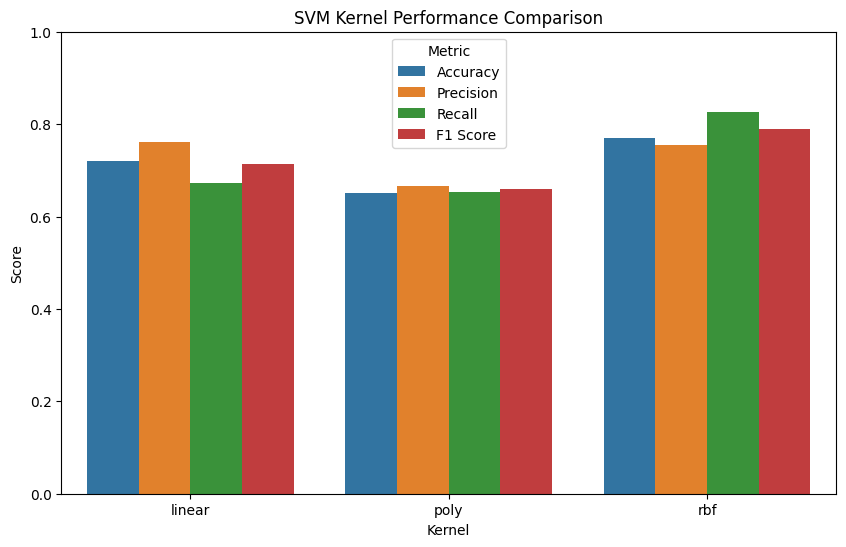

In [24]:
results_melted = results_df.melt(
    id_vars='Kernel',
    var_name='Metric',
    value_name='Score'
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_melted,
    x='Kernel',
    y='Score',
    hue='Metric'
)
plt.title("SVM Kernel Performance Comparison")
plt.ylim(0, 1)
plt.show()

In [25]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])
param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.01, 0.1, 1, 10, 100],
        'svc__gamma': ['scale', 0.001, 0.01, 0.1, 1]
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10],
        'svc__degree': [2, 3, 4],
        'svc__gamma': ['scale', 0.01, 0.1]
    }
]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svc__C': [0.01, 0.1, ...], 'svc__kernel': ['linear']}, {'svc__C': [0.01, 0.1, ...], 'svc__gamma': ['scale', 0.001, ...], 'svc__kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mo

In [26]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'svc__C': 1, 'svc__gamma': 1, 'svc__kernel': 'rbf'}

Best Cross-Validation Accuracy:
0.76


In [27]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print("Test Accuracy:",
      accuracy_score(y_test, y_pred_tuned))
print("Test Precision:",
      precision_score(y_test, y_pred_tuned))
print("Test Recall:",
      recall_score(y_test, y_pred_tuned))
print("Test F1 Score:",
      f1_score(y_test, y_pred_tuned))

Test Accuracy: 0.72
Test Precision: 0.7142857142857143
Test Recall: 0.7692307692307693
Test F1 Score: 0.7407407407407407


- Hyperparameter tuning using 5-fold stratified cross-validation identified an RBF kernel with C=1 and gamma=1 as the best configuration based on cross-validation accuracy of 76%. However, this tuned model achieved 72% accuracy on the unseen test set, which was lower than the 77% accuracy of the initial RBF model. Therefore, tuning did not improve the test-set performance in this experiment.

#### Strengths of SVM
- SVM performed reasonably well on this dataset, with the basic RBF model achieving 77% test accuracy and 79% F1-score. The RBF kernel was able to capture nonlinear relationships between the patient-related features and drug response. SVM is also suitable for datasets with a relatively small number of observations and numerical features.

#### Weaknesses of SVM
- SVM is sensitive to feature scaling and requires appropriate preprocessing. Its performance also depends strongly on hyperparameters such as C and gamma. In this experiment, hyperparameter tuning did not improve the test-set performance. In addition, SVM models can be less interpretable than simpler classification models, which can be an important limitation in healthcare-related applications.

#### Practical implications
- SVM can be used in pharmaceutical research to classify patients according to their predicted response to a drug based on available biological measurements. Such models may help identify patterns associated with positive treatment responses and support personalized medicine research. However, predictions from a machine learning model should not replace clinical judgment, and real-world healthcare applications require appropriate clinical validation and reliable patient data.